# **Project Introduction**
**Organization:** CodeAlpha

**Internship Domain:** Machine Learning

**Task Name:** Credit Scoring Model (Task 1)

**Date:** 4 March 2026

**Intern Name:** Hifza Nazir

# **Project Objective**
The goal of this project is to build a machine learning model that can predict a person's creditworthiness. Using historical financial data like income, debts, and payment history, the model classifies applicants as either "Good" or "Bad" credit risks. This helps financial institutions automate and improve their loan approval process.

# **Library Imports and Setup**

In [ ]:
# Importing necessary libraries for data handling and machine learning
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries successfully loaded!")

Libraries successfully loaded!


# **Data Loading and Initialization**

In [ ]:
# Loading the dataset and converting text to numbers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/german.csv"
columns = [f'Feature_{i}' for i in range(20)] + ['Target']
df = pd.read_csv(url, header=None, names=columns)

# Handling text data: This converts strings like 'A11' into numbers
# This is called Label Encoding
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes

print("Data converted to numbers! Now it's ready for the model.")
df.head()

Data converted to numbers! Now it's ready for the model.


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Target
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,1
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,2
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,1
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,1
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,2


# **Exploratory Data Analysis (EDA)**

/tmp/ipython-input-748/1598620330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='viridis')


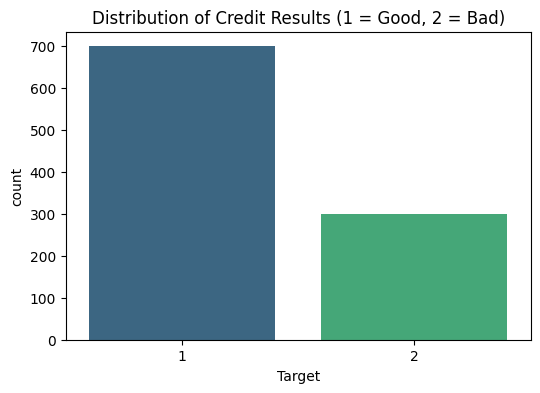

In [ ]:
# Plotting the distribution of Good vs Bad credit cases
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df, palette='viridis')
plt.title('Distribution of Credit Results (1 = Good, 2 = Bad)')
plt.show()

# **Data Splitting**

In [ ]:
# Separating features (X) and the label (y)
X = df.drop('Target', axis=1)
y = df['Target']

# Splitting data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 800 samples
Testing set size: 200 samples


# **Model Training**

In [ ]:
# Initializing the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model using the training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


# **Model Evaluation and Results**

Final Model Accuracy: 80.50%

Confusion Matrix:


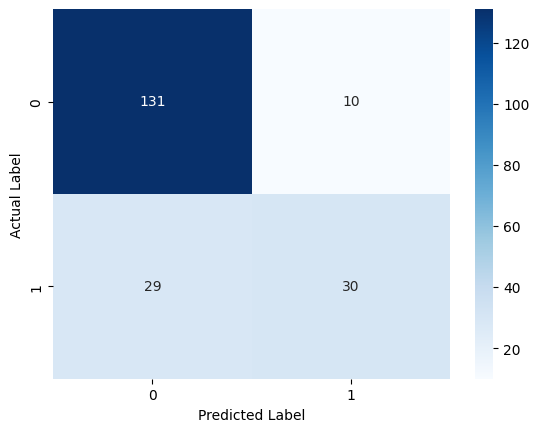

In [ ]:
# Making predictions on the unseen test data
predictions = model.predict(X_test)

# Calculating and printing accuracy
acc = accuracy_score(y_test, predictions)
print(f"Final Model Accuracy: {acc * 100:.2f}%")

# Showing the Confusion Matrix for detailed performance
print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()